# 🤖 Notebook 02 — Model 2: Statistical CNN NER (spaCy tok2vec)
**Technology**: spaCy v3 — Transition-based NER with CNN feature extraction (tok2vec)  
**Role in project**: Shows how a learned statistical model surpasses rigid rules by capturing context.

> **Prerequisites**: Run `00_EDA_Preprocessing.ipynb` first.


In [ ]:
!pip install spacy -q

In [1]:
import json, random
from pathlib import Path
from collections import defaultdict
import spacy
from spacy.training import Example
from spacy.util import minibatch, compounding
import matplotlib.pyplot as plt
import numpy as np

random.seed(42)
np.random.seed(42)

# ── Load data ────────────────────────────────────────────────────
train_raw = json.load(open("data/train.json", encoding="utf-8"))
test_raw  = json.load(open("data/test.json",  encoding="utf-8"))
ENTITY_LABELS = json.load(open("data/labels.json"))

print(f"Train: {len(train_raw)} | Test: {len(test_raw)}")
print("Labels:", ENTITY_LABELS)


Train: 160 | Test: 40
Labels: ['College Name', 'Companies worked at', 'Degree', 'Designation', 'Email Address', 'Graduation Year', 'Location', 'Name', 'Skills', 'Years of Experience']


## 1. Prepare spaCy Training Examples

In [2]:
nlp = spacy.blank("en")
ner = nlp.add_pipe("ner", last=True)

# Register all entity labels
for label in ENTITY_LABELS:
    ner.add_label(label)

def make_examples(data, nlp_model):
    """Convert JSON annotation format to spaCy Example objects."""
    examples, skipped = [], 0
    for text, ann in data:
        doc = nlp_model.make_doc(text)
        try:
            example = Example.from_dict(doc, ann)
            examples.append(example)
        except Exception as e:
            skipped += 1  # Skip samples with alignment errors
    if skipped:
        print(f"  ⚠️  Skipped {skipped} samples (alignment errors)")
    return examples

train_examples = make_examples(train_raw, nlp)
test_examples  = make_examples(test_raw,  nlp)

print(f"✅ Train examples: {len(train_examples)}")
print(f"   Test  examples: {len(test_examples)}")


c:\Users\blurtie\anaconda3\envs\nlp\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\blurtie\anaconda3\envs\nlp\Lib\site-packages\spacy\training\iob_utils.py:149: UserWarning: [W030] Some entities could not be aligned in the text "Aarti Pimplay Operations Center Shift Manager (OCS..." with entities "[[0, 13, 'Name'], [14, 52, 'Designation'], [76, 11...". Use `spacy.training.offsets_to_biluo_tags(nlp.make_doc(text), entities)` to check the alignment. Misaligned entities ('-') will be ignored during training.
  warnings.warn(
c:\Users\blurtie\anaconda3\envs\nlp\Lib\site-packages\spacy\training\iob_utils.py:149: UserWarning: [W030] Some entities could not be aligned in the text "Karthik G V Program Manager, Product Manager, Prod..." with entities "[[0, 11, 'Name'], [12, 28, 'Designation'], [136, 1...". Use `s

✅ Train examples: 160
   Test  examples: 40


c:\Users\blurtie\anaconda3\envs\nlp\Lib\site-packages\spacy\training\iob_utils.py:149: UserWarning: [W030] Some entities could not be aligned in the text "Senthil Kumar Senior Technical Lead - HCL Cisco  -..." with entities "[[0, 13, 'Name'], [14, 35, 'Designation'], [38, 41...". Use `spacy.training.offsets_to_biluo_tags(nlp.make_doc(text), entities)` to check the alignment. Misaligned entities ('-') will be ignored during training.
  warnings.warn(
c:\Users\blurtie\anaconda3\envs\nlp\Lib\site-packages\spacy\training\iob_utils.py:149: UserWarning: [W030] Some entities could not be aligned in the text "Puneeth R Escalation Specialist - HiPower Support ..." with entities "[[0, 9, 'Name'], [10, 31, 'Designation'], [34, 56,...". Use `spacy.training.offsets_to_biluo_tags(nlp.make_doc(text), entities)` to check the alignment. Misaligned entities ('-') will be ignored during training.
  warnings.warn(
c:\Users\blurtie\anaconda3\envs\nlp\Lib\site-packages\spacy\training\iob_utils.py:149: UserW

## 2. Train the CNN NER Model

In [3]:
# ── Hyperparameters ──────────────────────────────────────────────
N_EPOCHS   = 40
BATCH_SIZE = compounding(4.0, 16.0, 1.001)
DROP_RATE  = 0.4

# Initialize model (this builds the CNN tok2vec architecture)
optimizer = nlp.initialize(lambda: train_examples)

# ── Training loop ─────────────────────────────────────────────────
loss_history = []
print(f"Training for {N_EPOCHS} epochs...\n")
print(f"{'Epoch':>6} | {'NER Loss':>10} | {'Val F1':>8}")
print("-" * 32)

for epoch in range(1, N_EPOCHS + 1):
    random.shuffle(train_examples)
    losses = {}
    for batch in minibatch(train_examples, size=BATCH_SIZE):
        nlp.update(batch, drop=DROP_RATE, losses=losses, sgd=optimizer)
    
    ner_loss = losses.get("ner", 0)
    loss_history.append(ner_loss)

    # Evaluate every 5 epochs
    if epoch % 5 == 0 or epoch == N_EPOCHS:
        scores = nlp.evaluate(test_examples)
        val_f1 = scores.get('ents_f', 0)
        print(f"{epoch:6d} | {ner_loss:10.4f} | {val_f1:8.4f}")
    else:
        print(f"{epoch:6d} | {ner_loss:10.4f} |", end='\r')

print("\n✅ Training complete!")


Training for 40 epochs...

 Epoch |   NER Loss |   Val F1
--------------------------------
     5 |  4629.9248 |   0.3827
    10 |  3547.9517 |   0.4774
    15 |  3216.9917 |   0.5006
    20 |  3404.2124 |   0.4897
    25 |  2399.3669 |   0.5435
    30 |  2278.5693 |   0.5085
    35 |  2210.8616 |   0.5005
    40 |  2046.7856 |   0.5179

✅ Training complete!


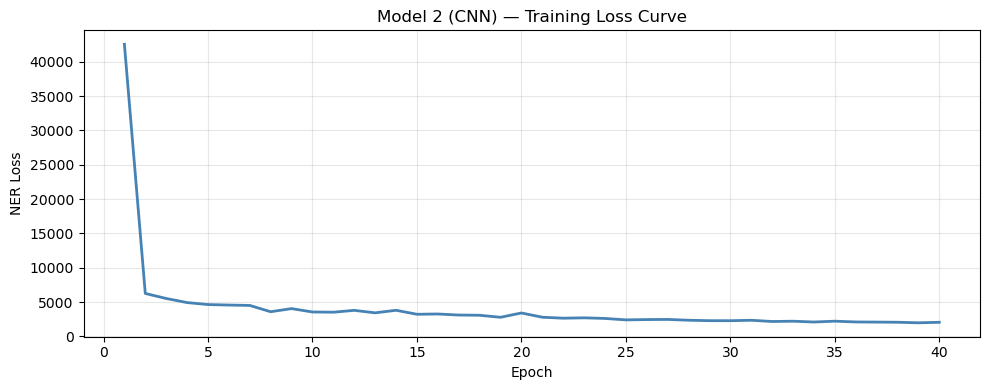

In [4]:
# ── Plot training loss ───────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(range(1, len(loss_history)+1), loss_history, color='steelblue', lw=2)
ax.set(xlabel='Epoch', ylabel='NER Loss', title='Model 2 (CNN) — Training Loss Curve')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("results/model2_loss.png", bbox_inches='tight', dpi=150)
plt.show()


## 3. Evaluate on Test Set

In [5]:
# ── Detailed per-entity metrics ──────────────────────────────────
tp = defaultdict(int)
fp = defaultdict(int)
fn = defaultdict(int)

for text, ann in test_raw:
    doc  = nlp(text)
    pred = {(e.start_char, e.end_char, e.label_) for e in doc.ents}
    gold = {(s, e, l) for s, e, l in ann['entities']}
    for span in pred:
        if span in gold: tp[span[2]] += 1
        else:            fp[span[2]] += 1
    for span in gold:
        if span not in pred: fn[span[2]] += 1

results = {}
for lbl in ENTITY_LABELS:
    p = tp[lbl] / (tp[lbl] + fp[lbl] + 1e-9)
    r = tp[lbl] / (tp[lbl] + fn[lbl] + 1e-9)
    f = 2*p*r / (p+r+1e-9)
    results[lbl] = {"precision": round(p,4), "recall": round(r,4), "f1": round(f,4)}

macro_p = np.mean([v['precision'] for v in results.values()])
macro_r = np.mean([v['recall']    for v in results.values()])
macro_f = np.mean([v['f1']        for v in results.values()])
results['__overall__'] = {"precision": round(macro_p,4),
                           "recall": round(macro_r,4),
                           "f1": round(macro_f,4)}

print(f"\n{'Label':30s} {'P':>6} {'R':>6} {'F1':>6}")
print("-" * 52)
for lbl in ENTITY_LABELS:
    m = results[lbl]
    print(f"{lbl:30s} {m['precision']:6.3f} {m['recall']:6.3f} {m['f1']:6.3f}")
print("-" * 52)
ov = results['__overall__']
print(f"{'MACRO AVERAGE':30s} {ov['precision']:6.3f} {ov['recall']:6.3f} {ov['f1']:6.3f}")



Label                               P      R     F1
----------------------------------------------------
College Name                    0.500  0.364  0.421
Companies worked at             0.523  0.283  0.368
Degree                          0.545  0.545  0.545
Designation                     0.623  0.430  0.509
Email Address                   0.769  0.698  0.732
Graduation Year                 0.500  0.172  0.256
Location                        0.508  0.478  0.492
Name                            0.969  0.775  0.861
Skills                          0.316  0.240  0.273
Years of Experience             0.000  0.000  0.000
----------------------------------------------------
MACRO AVERAGE                   0.525  0.399  0.446


In [6]:
# ── Save model & results ─────────────────────────────────────────
nlp.to_disk("data/model2_cnn")
output = {
    "model": "Model 2 - Statistical CNN (spaCy tok2vec)",
    "overall": results["__overall__"],
    "per_entity": {k: v for k, v in results.items() if k != "__overall__"}
}
json.dump(output, open("results/model2_results.json", "w"), indent=2)
print("✅ Model saved → data/model2_cnn/")
print("✅ Results saved → results/model2_results.json")
print(f"\n📌 Model 2 Macro F1: {ov['f1']:.4f}")


✅ Model saved → data/model2_cnn/
✅ Results saved → results/model2_results.json

📌 Model 2 Macro F1: 0.4457


## 4. Qualitative Analysis — Compare with Rule-Based

In [7]:
# Load model 1 results for quick comparison
m1 = json.load(open("results/model1_results.json"))

print("=== COMPARISON: Model 1 vs Model 2 (Overall) ===")
print(f"{'Metric':15s} {'Rule-Based':>12} {'CNN':>12} {'Δ':>8}")
print("-" * 50)
for metric in ['precision', 'recall', 'f1']:
    v1 = m1['overall'][metric]
    v2 = results['__overall__'][metric]
    delta = v2 - v1
    sign  = '+' if delta >= 0 else ''
    print(f"{metric.capitalize():15s} {v1:12.4f} {v2:12.4f} {sign}{delta:8.4f}")

print("\n→ CNN learns context and word embeddings — significantly better than rule matching.")


=== COMPARISON: Model 1 vs Model 2 (Overall) ===
Metric            Rule-Based          CNN        Δ
--------------------------------------------------
Precision             0.1049       0.5253 +  0.4204
Recall                0.3064       0.3985 +  0.0921
F1                    0.1348       0.4457 +  0.3109

→ CNN learns context and word embeddings — significantly better than rule matching.


In [8]:
# ── Qualitative: show predictions on a sample text ──────────────
sample_text = test_raw[0][0]
doc = nlp(sample_text)
print("CNN Predictions (first 12):")
for ent in doc.ents[:12]:
    print(f"  [{ent.label_:25s}] → \"{ent.text[:70]}\"")


CNN Predictions (first 12):
  [Email Address            ] → "indeed.com/r/Fenil-Francis/445e6b4cb0b43094"
  [Designation              ] → "Manager"
  [College Name             ] → "Masters equipments"
  [Companies worked at      ] → "Microsoft"
  [Degree                   ] → "B.Com in Computer Application"
  [College Name             ] → "Madurai Kamaraj University"
  [Skills                   ] → "PROBLEM SOLVING (Less than 1 year)"
